## Tutorial: Using the AEGIS python library

In [ ]:
from aegis.annotation import Annotation, detect_file_format
from aegis.genome import Genome
from urllib.request import urlretrieve
from wand.image import Image as WImage

### Retrieve example files

In [23]:
gff_filename, _ = urlretrieve("https://raw.githubusercontent.com/Tomsbiolab/aegis/refs/heads/main/tests/test_data/input/annotation/arabidopsis_araport11.gff3")
fasta_filename, _ = urlretrieve("https://raw.githubusercontent.com/Tomsbiolab/aegis/refs/heads/main/tests/test_data/input/fasta/arabidopsis_tair10.fasta")

### Load the genome and annotation

In [24]:
genome = Genome("Arabidopsis_genome", fasta_filename)
annotation = Annotation(gff_filename, "Arabidopsis_annotation", genome)


Arabidopsis_genome genome chromosomes/scaffolds: ['Chr4'] ...

Creating Arabidopsis_genome genome object took 0.0 seconds


Processing Arabidopsis_annotation_on_Arabidopsis_genome annotation object

gff3 file format detected for file='/tmp/tmppvherf_m'

Creating Arabidopsis_annotation_on_Arabidopsis_genome annotation object took 0.0 minutes

Correcting feature coordinates for Arabidopsis_annotation_on_Arabidopsis_genome
Corrected feature coordinates for Arabidopsis_annotation_on_Arabidopsis_genome

Whole update process for Arabidopsis_annotation_on_Arabidopsis_genome annotation object took 0.0 minutes



### Create subset with specific chromosomes and gene cap

In [4]:
list(annotation.chrs.keys())

['Chr4']

In [5]:
chosen_chromosomes = {"Chr4"}
annotation.subset(chosen_features=chosen_chromosomes, gene_cap=50)
annotation.export.gff(tag="Arabidopsis_subset.gff3", custom_path="subset_out/", subfolder=False)

Correcting feature coordinates for Arabidopsis_annotation_on_Arabidopsis_genome
Corrected feature coordinates for Arabidopsis_annotation_on_Arabidopsis_genome

Whole update process for Arabidopsis_annotation_on_Arabidopsis_genome annotation object took 0.0 minutes

Exporting Arabidopsis_annotation_on_Arabidopsis_genome gff to subset_out/Arabidopsis_subset.gff3.


### Generate all sequences (genes, transcripts, CDSs, proteins) and export different sequence types

In [6]:
annotation.export.genes(verbose=True, custom_path="subset_out/", custom_filename="Arabidopsis_subset_genes.fasta")
annotation.export.transcripts(only_main=True, verbose=True, custom_path="subset_out/", custom_filename="Arabidopsis_subset_transcripts.fasta")
annotation.export.CDSs(only_main=True, verbose=True, custom_path="subset_out/", custom_filename="Arabidopsis_subset_CDSs.fasta")
annotation.export.proteins(only_main=True, verbose=True, custom_path="subset_out/", custom_filename="Arabidopsis_subset_proteins.fasta")

### Generate and export promoters

In [7]:
annotation.generate_promoters(promoter_size=2000, promoter_type="standard")
annotation.export.promoters(only_main=True, verbose=True, custom_path="subset_out/", custom_filename="Arabidopsis_subset_promoters.fasta")

### Statistics

In [10]:
annotation.stats.update(export=True, custom_path="subset_out/")

print(f"Total genes: {annotation.stats.data.get('gene', 0)}")
print(f"Coding genes: {annotation.stats.data.get('coding_genes', 0)}")
print(f"Non-coding genes: {annotation.stats.data.get('noncoding_genes', 0)}")

Total genes: 50
Coding genes: 33
Non-coding genes: 17


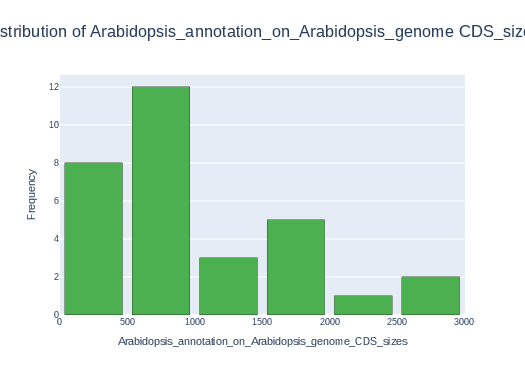

In [11]:
WImage(filename='subset_out/out_stats/Arabidopsis_annotation_on_Arabidopsis_genome_CDS_sizes.pdf')

### Remove genes with small CDSs, transposable elements, and keep only mRNA. Clean up IDs and standardise naming

In [12]:
annotation.remove_genes_with_small_CDSs(CDS_threshold=300)
annotation.remove_TE_genes()
annotation.filter_by_rna_class(rna_classes=['mRNA'])
annotation.rename_ids(prefix="CLEANED", spacer=100)
annotation.export.gff(tag="Arabidopsis_subset_cleaned.gff3", custom_path="subset_out/", subfolder=False)

Correcting feature coordinates for Arabidopsis_annotation_on_Arabidopsis_genome
Corrected feature coordinates for Arabidopsis_annotation_on_Arabidopsis_genome

Whole update process for Arabidopsis_annotation_on_Arabidopsis_genome annotation object took 0.0 minutes

Correcting feature coordinates for Arabidopsis_annotation_on_Arabidopsis_genome
Corrected feature coordinates for Arabidopsis_annotation_on_Arabidopsis_genome

Whole update process for Arabidopsis_annotation_on_Arabidopsis_genome annotation object took 0.0 minutes

Correcting feature coordinates for Arabidopsis_annotation_on_Arabidopsis_genome
Corrected feature coordinates for Arabidopsis_annotation_on_Arabidopsis_genome

Whole update process for Arabidopsis_annotation_on_Arabidopsis_genome annotation object took 0.0 minutes


Renaming Arabidopsis_annotation_on_Arabidopsis_genome ids with prefix='CLEANED', changing={'gene', 'exon', 'transcript', 'CDS'} features took 0.0 minutes
Exporting Arabidopsis_annotation_on_Arabidopsis

In [21]:
!head -n 20 subset_out/Arabidopsis_subset_cleaned.gff3

##gff-version 3
##gff-3
##sequence-region   Chr4 1180 18584524
#chromosome assembly: TAIR10.1
#genome annotation (gene structure): Araport11
#symbol and full name data generated: 2023-07-01 by TAIR
Chr4	Araport11	gene	306869	310517	.	-	.	ID=CLEANEDChr4g00100
Chr4	Araport11	mRNA	306869	310484	.	-	.	ID=CLEANEDChr4g00100_t001;Parent=CLEANEDChr4g00100
Chr4	Araport11	mRNA	306948	310517	.	-	.	ID=CLEANEDChr4g00100_t002;Parent=CLEANEDChr4g00100
Chr4	Araport11	exon	306869	308037	.	-	.	ID=CLEANEDChr4g00100_e010;Parent=CLEANEDChr4g00100_t001
Chr4	Araport11	exon	306948	307358	.	-	.	ID=CLEANEDChr4g00100_e009;Parent=CLEANEDChr4g00100_t002
Chr4	Araport11	exon	307769	308037	.	-	.	ID=CLEANEDChr4g00100_e008;Parent=CLEANEDChr4g00100_t002
Chr4	Araport11	exon	308128	308223	.	-	.	ID=CLEANEDChr4g00100_e007;Parent=CLEANEDChr4g00100_t001,CLEANEDChr4g00100_t002
Chr4	Araport11	exon	308375	308749	.	-	.	ID=CLEANEDChr4g00100_e006;Parent=CLEANEDChr4g00100_t001,CLEANEDChr4g00100_t002
Chr4	Araport11	exon	308859	309120